In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sorted_portfolios import get_sorted_index, get_sorted_portfolio
from utils import *
from signals import get_prc_mom
from visualization import plot_group_cum, plot_solo_cum

plt.style.use("default")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# CRSP data
crsp = pd.read_csv("csrp_msf.csv", index_col=0)
# Construct dfs
dfs = {}
dfs['prc'] = np.abs(date_cusip_pivot(crsp, 'prc_adj'))
dfs['vol'] = date_cusip_pivot(crsp, 'vol')
dfs['ret'] = get_simple_ret(dfs['prc'])
vol_q = np.nanquantile(dfs['vol'], .7, axis=1,).reshape(-1, 1)
dfs['idx_vol_threshold'] = create_empty_df(dfs['ret'])
dfs['idx_vol_threshold'][dfs['vol'] >= vol_q] = 1

In [12]:
# Price momentum
dfs['mom_prc'] = get_prc_mom(dfs['ret'], 12, 1)

/Users/pengchengzhou/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


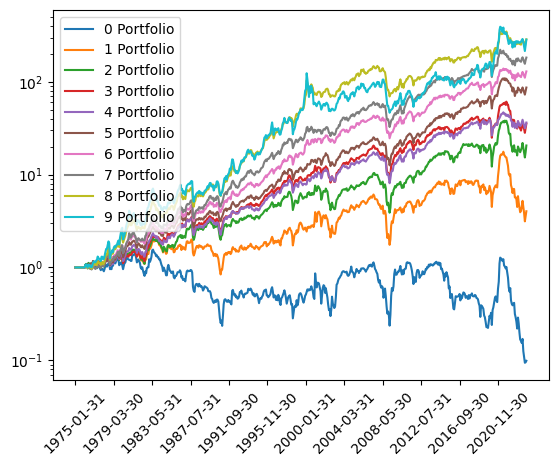

In [49]:
# Portfolio
mom_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(dfs['mom_prc'] * dfs['idx_vol_threshold'])
)
# Visualization
plot_group_cum(mom_portfolio)

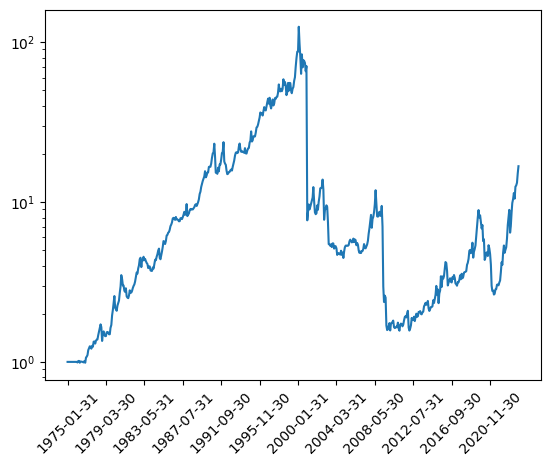

In [51]:
plot_solo_cum(mom_portfolio.iloc[:, -1] - mom_portfolio.iloc[:, 0])

## Comp Funda

In [162]:
comp_funda_og = pd.read_csv("comp_funda.csv", index_col=0).rename(columns={"datadate": "date"})
# comp_funda['profit_margin'] = comp_funda.eval("ni/sale")
comp_funda_og['cusip'] = comp_funda_og['cusip'].apply(lambda x: str(x)[:8])
comp_funda_og = comp_funda_og[comp_funda_og.datafmt == 'STD'].reset_index(drop=True)
# comp_funda = comp_funda[comp_funda.indfmt == 'INDL']
# comp_funda = comp_funda[comp_funda.cusip != 'nan'].drop_duplicates(subset=['date', 'cusip']).sort_values(['cusip', 'date'])

/var/folders/ts/rncgzs1x0z9fwh0s8vnmhs2h0000gn/T/ipykernel_58829/2628737403.py:1: DtypeWarning: Columns (9,11,12,13,17,18,23,27,31,34,35,36,921,947,948) have mixed types. Specify dtype option on import or set low_memory=False.
  comp_funda_og = pd.read_csv("comp_funda.csv", index_col=0).rename(columns={"datadate": "date"})


In [163]:
comp_funda = comp_funda_og[comp_funda_og.cshfd > 0]
comp_funda['eps'] = comp_funda.ni / comp_funda.cshfd

/var/folders/ts/rncgzs1x0z9fwh0s8vnmhs2h0000gn/T/ipykernel_58829/2574802558.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comp_funda['eps'] = comp_funda.ni / comp_funda.cshfd


In [169]:
feature_name = "eps"
temp = comp_funda.groupby("cusip").apply(lambda x: cusip_val_pct(x, feature_name)).drop_duplicates(subset=['date', 'cusip'], keep=False)
temp =  date_cusip_pivot(temp, f'{feature_name}_pct').reindex(columns=dfs['ret'].columns)
temp = get_time_merge(temp, dfs['ret']).ffill(limit=12)
dfs[f'{feature_name}_pct'] = temp

/var/folders/ts/rncgzs1x0z9fwh0s8vnmhs2h0000gn/T/ipykernel_58829/1637193767.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp = comp_funda.groupby("cusip").apply(lambda x: cusip_val_pct(x, feature_name)).drop_duplicates(subset=['date', 'cusip'], keep=False)


/Users/pengchengzhou/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


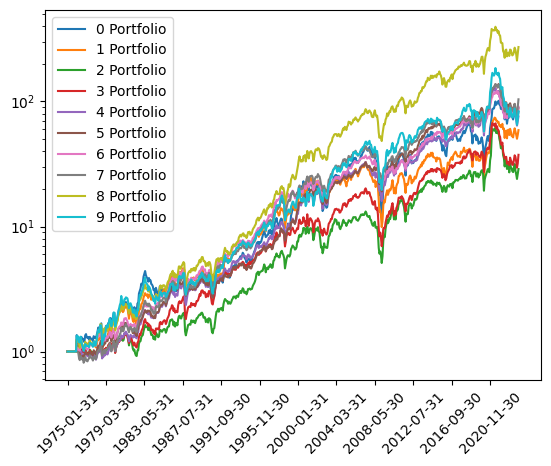

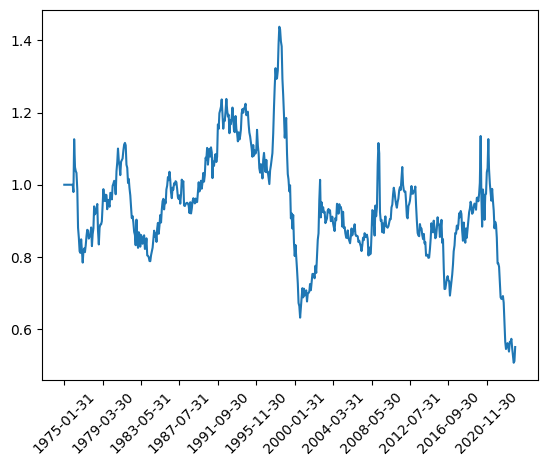

In [170]:
# Portfolio
funda_mom_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        dfs[f'{feature_name}_pct'] * dfs['idx_vol_threshold'], 
        # quantiles=np.array([0.3, 0.7])
        )
)
# Visualization
plot_group_cum(funda_mom_portfolio)
plot_solo_cum(funda_mom_portfolio.iloc[:, -1] - funda_mom_portfolio.iloc[:, 0], False)

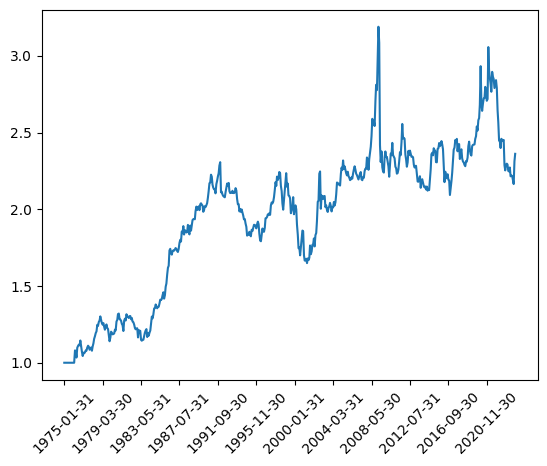

In [77]:
plot_solo_cum(pm_mom_portfolio.iloc[:, -1] - pm_mom_portfolio.iloc[:, 0], False)